In [3]:
import torch
import numpy as np
import pandas as pd
import seaborn as sns
import torch.nn as nn
from datetime import datetime
import matplotlib.pyplot as plt
from torch.utils.data import Dataset, DataLoader

In [4]:
df = pd.read_excel("train.xlsx")
df.head()

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
0,9117000170,20150505T000000,268643,4,2.25,1810,9240,2.0,0,0,...,7,1810,0,1961,0,98055,47.4362,-122.187,1660,9240
1,6700390210,20140708T000000,245000,3,2.50,1600,2788,2.0,0,0,...,7,1600,0,1992,0,98031,47.4034,-122.187,1720,3605
2,7212660540,20150115T000000,200000,4,2.50,1720,8638,2.0,0,0,...,8,1720,0,1994,0,98003,47.2704,-122.313,1870,7455
3,8562780200,20150427T000000,352499,2,2.25,1240,705,2.0,0,0,...,7,1150,90,2009,0,98027,47.5321,-122.073,1240,750
4,7760400350,20141205T000000,232000,3,2.00,1280,13356,1.0,0,0,...,7,1280,0,1994,0,98042,47.3715,-122.074,1590,8071


In [3]:
df.columns

Index(['id', 'date', 'price', 'bedrooms', 'bathrooms', 'sqft_living',
       'sqft_lot', 'floors', 'waterfront', 'view', 'condition', 'grade',
       'sqft_above', 'sqft_basement', 'yr_built', 'yr_renovated', 'zipcode',
       'lat', 'long', 'sqft_living15', 'sqft_lot15'],
      dtype='object')

In [4]:
df.shape

(16209, 21)

In [5]:
df.isna().values.any()

np.False_

<Axes: ylabel='Frequency'>

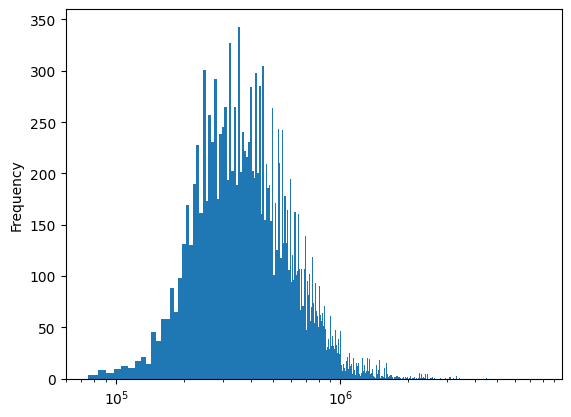

In [6]:
df.price.plot.hist(bins=1000, logx=True)

In [7]:
df.lat.between(-90, 90).all(), df.long.between(-180, 180).all()

(np.True_, np.True_)

In [8]:
id = df.id
lon = df.long
lat = df.lat
log_price = np.log(df.price.values)

df2 = df.assign(log_price=log_price)
df2 = df2.drop(columns=["id", "long", "lat", "price", "sqft_basement"], axis=1)

df2.head()

,date,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,yr_built,yr_renovated,zipcode,sqft_living15,sqft_lot15,log_price
0,20150505T000000,4,2.25,1810,9240,2.0,0,0,3,7,1810,1961,0,98055,1660,9240,12.501139
1,20140708T000000,3,2.50,1600,2788,2.0,0,0,4,7,1600,1992,0,98031,1720,3605,12.409013
2,20150115T000000,4,2.50,1720,8638,2.0,0,0,3,8,1720,1994,0,98003,1870,7455,12.206073
3,20150427T000000,2,2.25,1240,705,2.0,0,0,3,7,1150,2009,0,98027,1240,750,12.772803
4,20141205T000000,3,2.00,1280,13356,1.0,0,0,3,7,1280,1994,0,98042,1590,8071,12.354493


<Axes: ylabel='Frequency'>

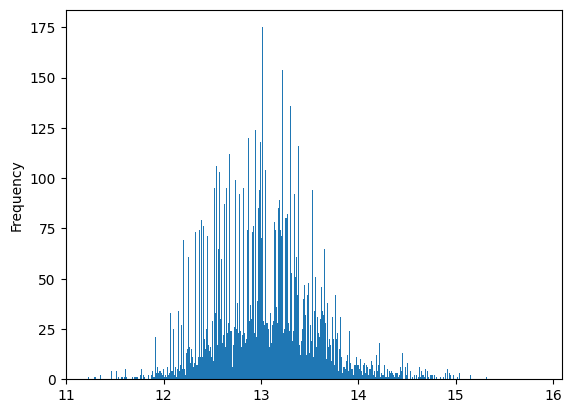

In [9]:
df2.log_price.plot.hist(bins=1000)

In [10]:
dt = df2.date.apply(lambda x: datetime.strptime(x, "%Y%m%dT%H%M%S"))

print(max(dt.apply(lambda x: x.hour)))
print(max(dt.apply(lambda x: x.minute)))
print(max(dt.apply(lambda x: x.second)))

0
0
0


In [11]:
sale_year = dt.apply(lambda x: x.year)
age = dt.apply(lambda x: x.year) - df2.yr_built
age.describe()

count    16209.000000
mean        43.169227
std         29.373872
min         -1.000000
25%         17.000000
50%         39.000000
75%         63.000000
max        115.000000
dtype: float64

In [12]:
df2[age == -1][["date", "yr_built"]]

,date,yr_built
829,20140617T000000,2015
1396,20140624T000000,2015
1644,20140731T000000,2015
6426,20141125T000000,2015
7362,20140828T000000,2015
8334,20140801T000000,2015
14628,20140625T000000,2015
15515,20140826T000000,2015
15585,20140709T000000,2015
15684,20140520T000000,2015


In [13]:
effective_age = sale_year - df2.yr_renovated.where(df2.yr_renovated != 0, df2.yr_built)
effective_age.describe()

count    16209.000000
mean        40.813684
std         28.785364
min         -1.000000
25%         15.000000
50%         37.000000
75%         60.000000
max        115.000000
dtype: float64

In [14]:
df2[effective_age == -1][["date", "yr_built", "yr_renovated"]]

,date,yr_built,yr_renovated
829,20140617T000000,2015,0
1396,20140624T000000,2015,0
1644,20140731T000000,2015,0
6426,20141125T000000,2015,0
7362,20140828T000000,2015,0
8334,20140801T000000,2015,0
12644,20140522T000000,1923,2015
12880,20140728T000000,1922,2015
14628,20140625T000000,2015,0
14709,20140606T000000,1956,2015


In [15]:
age[age == -1] = 0
effective_age[effective_age == -1] = 0

In [16]:
is_renovated = df2.yr_renovated.where(df2.yr_renovated == 0, 1)
is_renovated.describe()

count    16209.000000
mean         0.041458
std          0.199354
min          0.000000
25%          0.000000
50%          0.000000
75%          0.000000
max          1.000000
Name: yr_renovated, dtype: float64

In [17]:
pd.DataFrame({"age": age, "effective_age": effective_age, "is_renovated": is_renovated}).corr()

,age,effective_age,is_renovated
age,1.000000,0.910213,0.228188
effective_age,0.910213,1.000000,-0.160618
is_renovated,0.228188,-0.160618,1.000000


In [18]:
df3 = df2.assign(effective_age=effective_age.values, is_renovated=is_renovated)
date = df3.date
df3 = df3.drop(columns=["date", "yr_built", "yr_renovated"], axis=1)

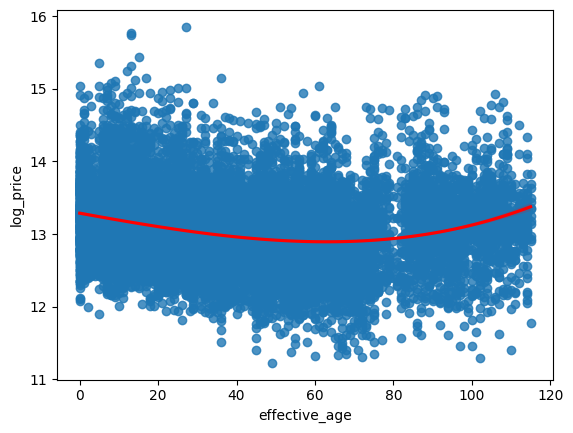

In [19]:
sns.regplot(x="effective_age", y="log_price", data=df3, order=3, line_kws=dict(color="r"))
plt.show()

<Axes: xlabel='is_renovated', ylabel='log_price'>

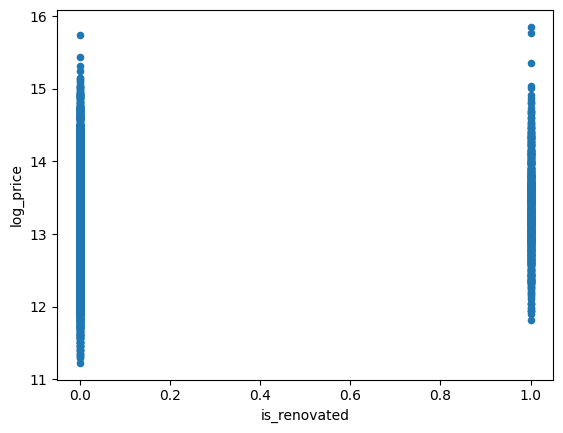

In [20]:
df3.plot.scatter(x="is_renovated", y="log_price")

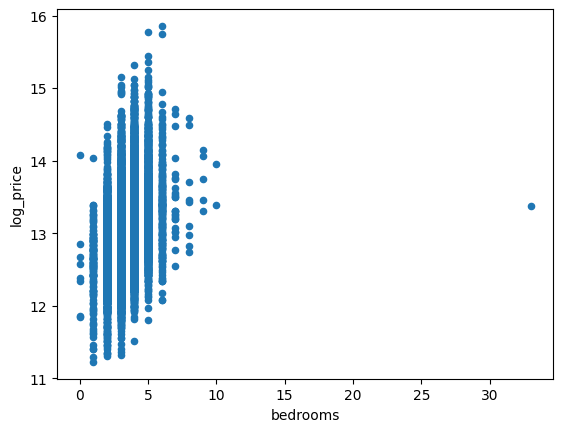

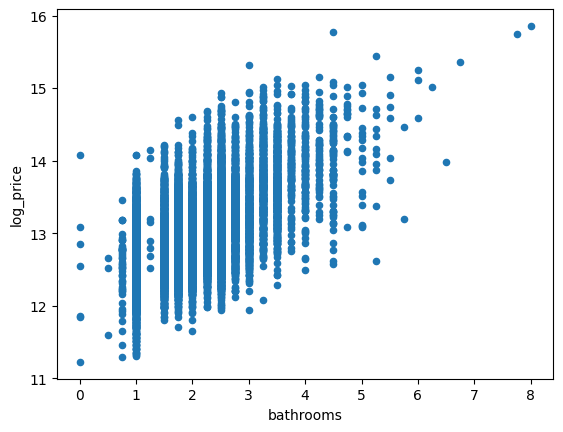

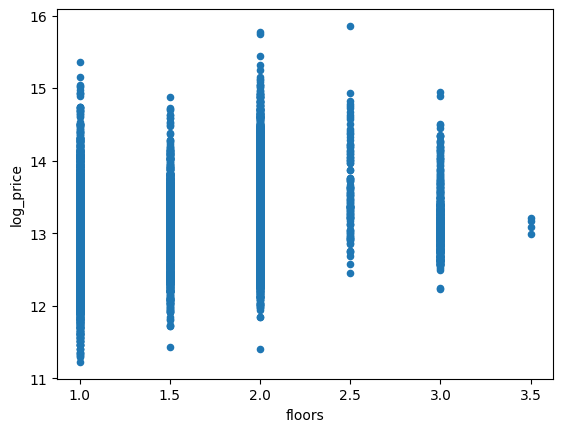

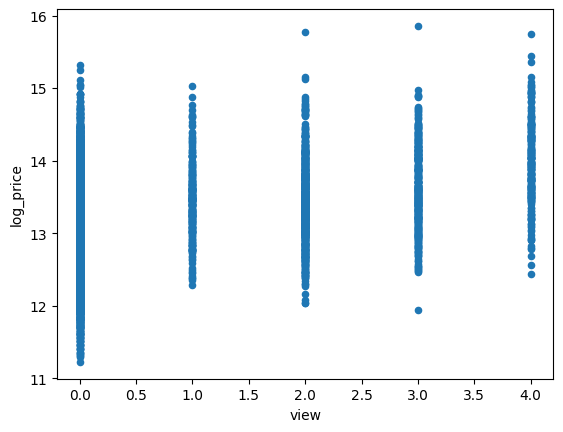

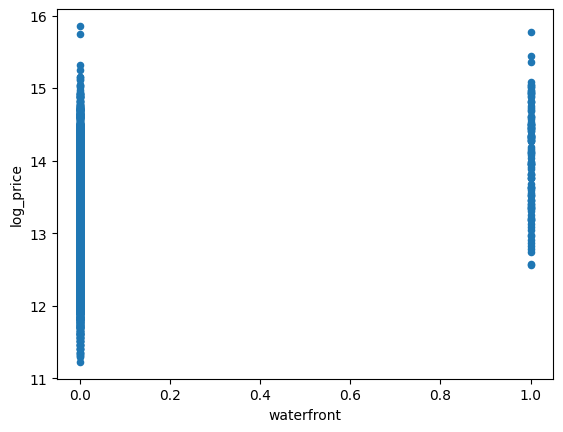

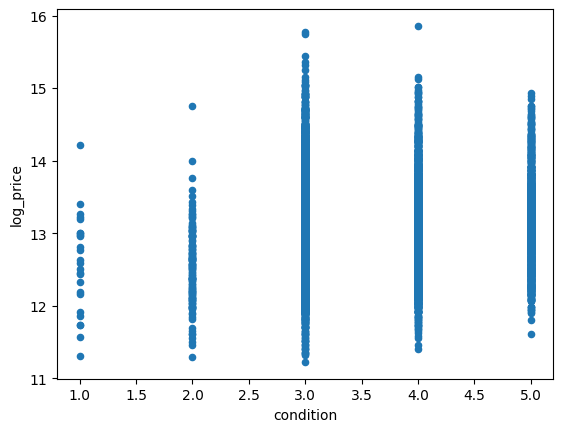

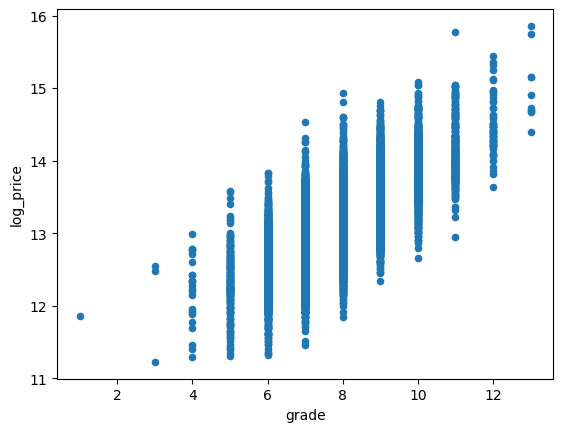

In [21]:
for col in ["bedrooms", "bathrooms", "floors", "view", "waterfront", "condition", "grade"]:
    df3.plot.scatter(x=col, y="log_price")
plt.show()

In [22]:
df[df.bedrooms > 11]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
3193,2402100895,20140625T000000,640000,33,1.75,1620,6000,1.0,0,0,...,7,1040,580,1947,0,98103,47.6878,-122.331,1330,4700


In [23]:
df.sqft_living.describe()

count    16209.000000
mean      2073.274601
std        907.009491
min        290.000000
25%       1430.000000
50%       1910.000000
75%       2550.000000
max      12050.000000
Name: sqft_living, dtype: float64

In [24]:
df.price.describe()

count    1.620900e+04
mean     5.374703e+05
std      3.603036e+05
min      7.500000e+04
25%      3.200000e+05
50%      4.500000e+05
75%      6.400000e+05
max      7.700000e+06
Name: price, dtype: float64

In [25]:
df3 = df3[df3.bedrooms < 33]

In [26]:
df3.zipcode.describe()

count    16208.000000
mean     98077.973223
std         53.356565
min      98001.000000
25%      98033.000000
50%      98065.000000
75%      98117.000000
max      98199.000000
Name: zipcode, dtype: float64

In [27]:
df3.zipcode.unique()

array([98055, 98031, 98003, 98027, 98042, 98117, 98155, 98072, 98001,
       98034, 98177, 98006, 98023, 98166, 98075, 98092, 98133, 98014,
       98065, 98115, 98144, 98038, 98109, 98112, 98074, 98029, 98136,
       98178, 98125, 98199, 98056, 98032, 98058, 98103, 98116, 98059,
       98030, 98052, 98033, 98102, 98011, 98040, 98146, 98022, 98118,
       98028, 98008, 98119, 98108, 98007, 98070, 98168, 98004, 98077,
       98107, 98198, 98045, 98005, 98053, 98126, 98188, 98039, 98106,
       98010, 98002, 98024, 98105, 98019, 98122, 98148])

In [28]:
test = pd.read_excel("test.xlsx")

In [29]:
df3.zipcode.unique().sort() == test.zipcode.unique().sort()

True

In [30]:
df3.loc[:, "zipcode"] = df3.zipcode.astype("category").cat.codes.astype("long")
df3.zipcode

0        30
1        19
2         2
3        15
4        26
         ..
16204    55
16205    13
16206    29
16207    64
16208    26
Name: zipcode, Length: 16208, dtype: int64

<Axes: ylabel='Frequency'>

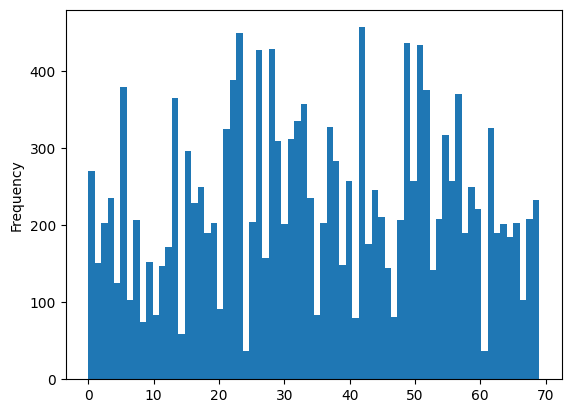

In [31]:
df3.zipcode.plot.hist(bins=df3.zipcode.nunique())

<Axes: xlabel='zipcode', ylabel='log_price'>

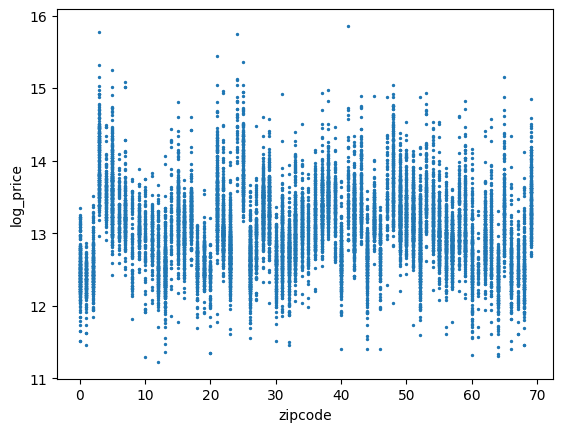

In [32]:
df3.plot.scatter(x="zipcode", y="log_price", s=2)

In [33]:
zipcode = df3.zipcode
df3 = df3.drop("zipcode", axis=1)
df3 = df3.astype("float32")

In [34]:
df3.sqft_living = np.log(df3.sqft_living.values)
df3.sqft_lot = np.log(df3.sqft_lot.values)
df3.sqft_above= np.log(df3.sqft_above.values)
df3.sqft_living15 = np.log(df3.sqft_living15.values)
df3.sqft_lot15 = np.log(df3.sqft_lot15.values)

<Axes: xlabel='sqft_living', ylabel='log_price'>

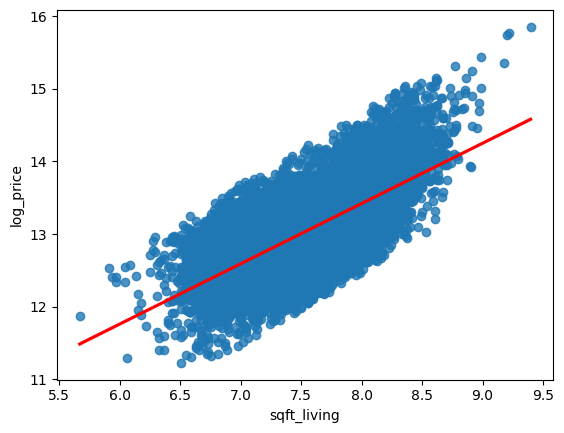

In [35]:
sns.regplot(x="sqft_living", y="log_price", data=df3, order=1, line_kws=dict(color="r"))

In [36]:
log_price = df3.log_price
df3 = df3.drop("log_price", axis=1)
log_price

0        12.501139
1        12.409014
2        12.206073
3        12.772803
4        12.354492
           ...    
16204    12.842649
16205    12.899095
16206    13.262125
16207    12.409014
16208    12.660328
Name: log_price, Length: 16208, dtype: float32

In [37]:
df3.head()

,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,condition,grade,sqft_above,sqft_living15,sqft_lot15,effective_age,is_renovated
0,4.0,2.25,7.501082,9.131297,2.0,0.0,0.0,3.0,7.0,7.501082,7.414573,9.131297,54.0,0.0
1,3.0,2.50,7.377759,7.933080,2.0,0.0,0.0,4.0,7.0,7.377759,7.450079,8.190077,22.0,0.0
2,4.0,2.50,7.450079,9.063927,2.0,0.0,0.0,3.0,8.0,7.450079,7.533694,8.916640,21.0,0.0
3,2.0,2.25,7.122867,6.558198,2.0,0.0,0.0,3.0,7.0,7.047517,7.122867,6.620073,6.0,0.0
4,3.0,2.00,7.154615,9.499721,1.0,0.0,0.0,3.0,7.0,7.154615,7.371490,8.996033,20.0,0.0


In [38]:
df3.shape

(16208, 14)

<Axes: >

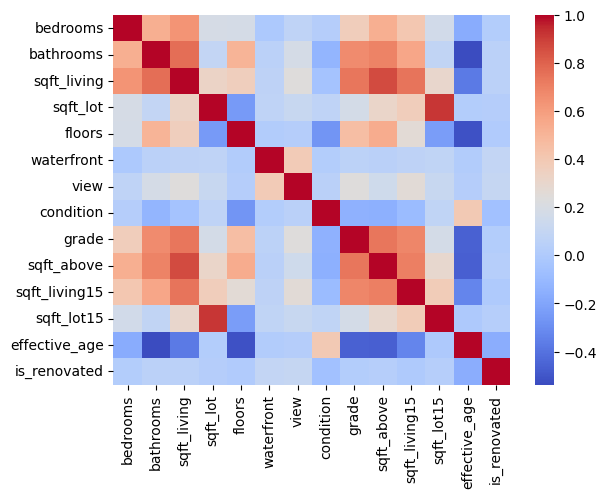

In [39]:
sns.heatmap(df3.corr(), cmap="coolwarm")

In [40]:
class MLP(nn.Module):

    def __init__(self, in_dim, hid_dim, out_dim, num_emb):

        super().__init__()

        self.dense_layer1 = nn.Sequential(
            nn.Linear(in_dim, hid_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hid_dim)
        )

        self.emb_layer = nn.Embedding(num_emb, hid_dim)

        self.dense_layer2 = nn.Sequential(
            nn.Linear(hid_dim, hid_dim),
            nn.ReLU(),
            nn.BatchNorm1d(hid_dim),
            nn.Linear(hid_dim, out_dim)
        )

    def forward(self, x, zip):
        return self.dense_layer2(self.dense_layer1(x) + self.emb_layer(zip))

In [41]:
class SatelliteDataset(Dataset):

    def __init__(self, X, y, id, lat, lon, zip, date):

        self.X = torch.from_numpy(X.values.copy())
        self.y = torch.from_numpy(y.values.copy())
        self.id = torch.from_numpy(id.values.copy())
        self.lat = torch.from_numpy(lat.values.copy())
        self.lon = torch.from_numpy(lon.values.copy())
        self.zip = torch.from_numpy(zip.values.copy())
        self.date = torch.from_numpy(date.values.copy())

    def __getitem__(self, idx):
        return self.X[idx], self.y[idx], self.id[idx], self.lat[idx], self.lon[idx], self.zip[idx], self.date[idx]

    def __len__(self):
        return self.X.shape[0]

In [42]:
dataset = SatelliteDataset(df3, log_price, id, lat, lon, zipcode, sale_year)
dataset[0]

(tensor([ 4.0000,  2.2500,  7.5011,  9.1313,  2.0000,  0.0000,  0.0000,  3.0000,
          7.0000,  7.5011,  7.4146,  9.1313, 54.0000,  0.0000]),
 tensor(12.5011),
 tensor(9117000170),
 tensor(47.4362, dtype=torch.float64),
 tensor(-122.1870, dtype=torch.float64),
 tensor(30),
 tensor(2015))

In [43]:
loader = DataLoader(dataset, batch_size=64, shuffle=True)

In [44]:
X, y, id, lat, lon, zip, date = next(iter(loader))
model = MLP(X.shape[-1], 20, 1, zipcode.nunique())
pred = model(X, zip)
pred.shape

torch.Size([64, 1])

In [45]:
sum([param.numel() for param in model.parameters()])

2221

In [46]:
df[df.waterfront == 1]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
131,2726049034,20141110T000000,2000000,3,3.25,2610,16387,2.0,1,4,...,9,2610,0,2006,0,98125,47.7175,-122.278,2590,12958
455,1724069062,20140714T000000,1365000,2,3.25,2700,3444,3.0,1,3,...,9,2700,0,1990,0,98075,47.5684,-122.060,2710,3444
656,3126059023,20150303T000000,3395000,4,3.50,4730,47870,1.0,1,4,...,10,2940,1790,1954,0,98033,47.6967,-122.216,3250,49346
699,7567600030,20150127T000000,750000,5,1.75,2640,13290,1.0,1,4,...,8,1400,1240,1954,0,98178,47.5022,-122.223,2400,11942
912,8073000480,20140722T000000,869000,2,1.75,1900,13122,1.0,1,4,...,7,1100,800,1954,0,98178,47.5121,-122.248,1650,13160
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15318,2024069008,20140619T000000,2200000,5,4.75,5990,10450,2.0,1,4,...,11,4050,1940,2002,0,98027,47.5554,-122.077,3330,14810
15801,7567600045,20140827T000000,825000,2,1.00,1150,12775,1.0,1,4,...,6,1150,0,1908,0,98178,47.5020,-122.222,2440,11852
15886,222029026,20140917T000000,340000,2,0.75,1060,48292,1.0,1,2,...,6,560,500,1947,0,98070,47.4285,-122.511,750,80201
16147,9362000040,20140623T000000,3400000,3,4.50,5230,17826,2.0,1,4,...,10,3740,1490,2005,0,98040,47.5348,-122.243,3670,17826


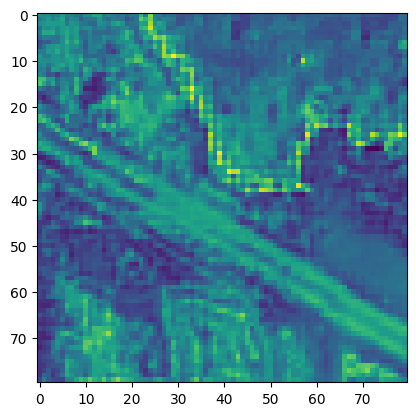

In [47]:
data = np.load(".\\data\\2024069008.npy")
plt.imshow(data[:, :, 2])

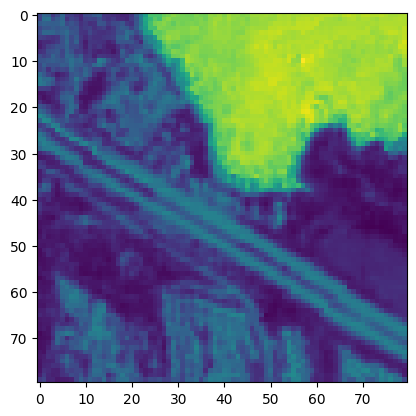

In [60]:
plt.imshow(data[:, :, 1])

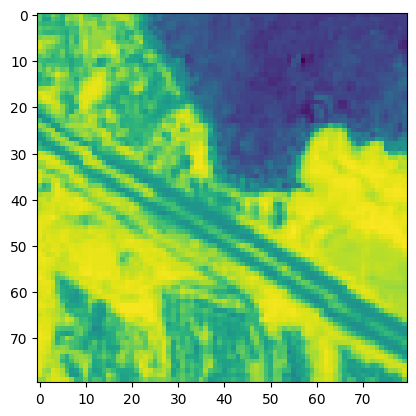

In [61]:
plt.imshow(data[:, :, 0])

In [55]:
df.id.nunique()

16110

In [57]:
df.shape

(16209, 21)

In [52]:
df[df.duplicated(["id"])]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
2435,5332200530,20150424T000000,1015000,5,2.50,2350,4000,2.0,0,0,...,9,2350,0,1993,0,98112,47.6265,-122.296,1840,4000
3218,2892700041,20140714T000000,168000,3,1.50,1370,7439,1.0,0,0,...,6,1370,0,1963,0,98055,47.4499,-122.189,2350,3370
3255,2767603612,20140512T000000,500000,2,2.25,1290,1334,3.0,0,0,...,8,1290,0,2007,0,98107,47.6719,-122.382,1350,1334
3316,6021500970,20150407T000000,874950,2,1.00,1080,4000,1.0,0,0,...,7,1080,0,1940,0,98117,47.6902,-122.387,1530,4240
4439,7977201065,20150305T000000,740000,3,1.75,1380,4590,1.0,0,0,...,7,930,450,1950,0,98115,47.6841,-122.293,1320,4692
...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...,...
15618,726049190,20141002T000000,287500,3,1.00,1810,7200,1.0,0,0,...,7,1130,680,1954,0,98133,47.7493,-122.351,1810,8100
15792,1523049207,20150114T000000,220000,4,2.00,1700,8043,1.0,0,0,...,7,850,850,1954,0,98168,47.4758,-122.288,1540,13260
15992,1954420170,20141113T000000,580000,3,2.50,2150,7484,2.0,0,0,...,8,2150,0,1988,0,98074,47.6191,-122.043,2150,6879
16165,1721801010,20140903T000000,225000,3,1.00,1790,6120,1.0,0,0,...,6,1790,0,1937,1964,98146,47.5080,-122.337,830,6120


In [56]:
df[df.id == 5332200530]

,id,date,price,bedrooms,bathrooms,sqft_living,sqft_lot,floors,waterfront,view,...,grade,sqft_above,sqft_basement,yr_built,yr_renovated,zipcode,lat,long,sqft_living15,sqft_lot15
932,5332200530,20140613T000000,910000,5,2.5,2350,4000,2.0,0,0,...,9,2350,0,1993,0,98112,47.6265,-122.296,1840,4000
2435,5332200530,20150424T000000,1015000,5,2.5,2350,4000,2.0,0,0,...,9,2350,0,1993,0,98112,47.6265,-122.296,1840,4000
